c:\Users\USER\.conda\envs\vlm\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


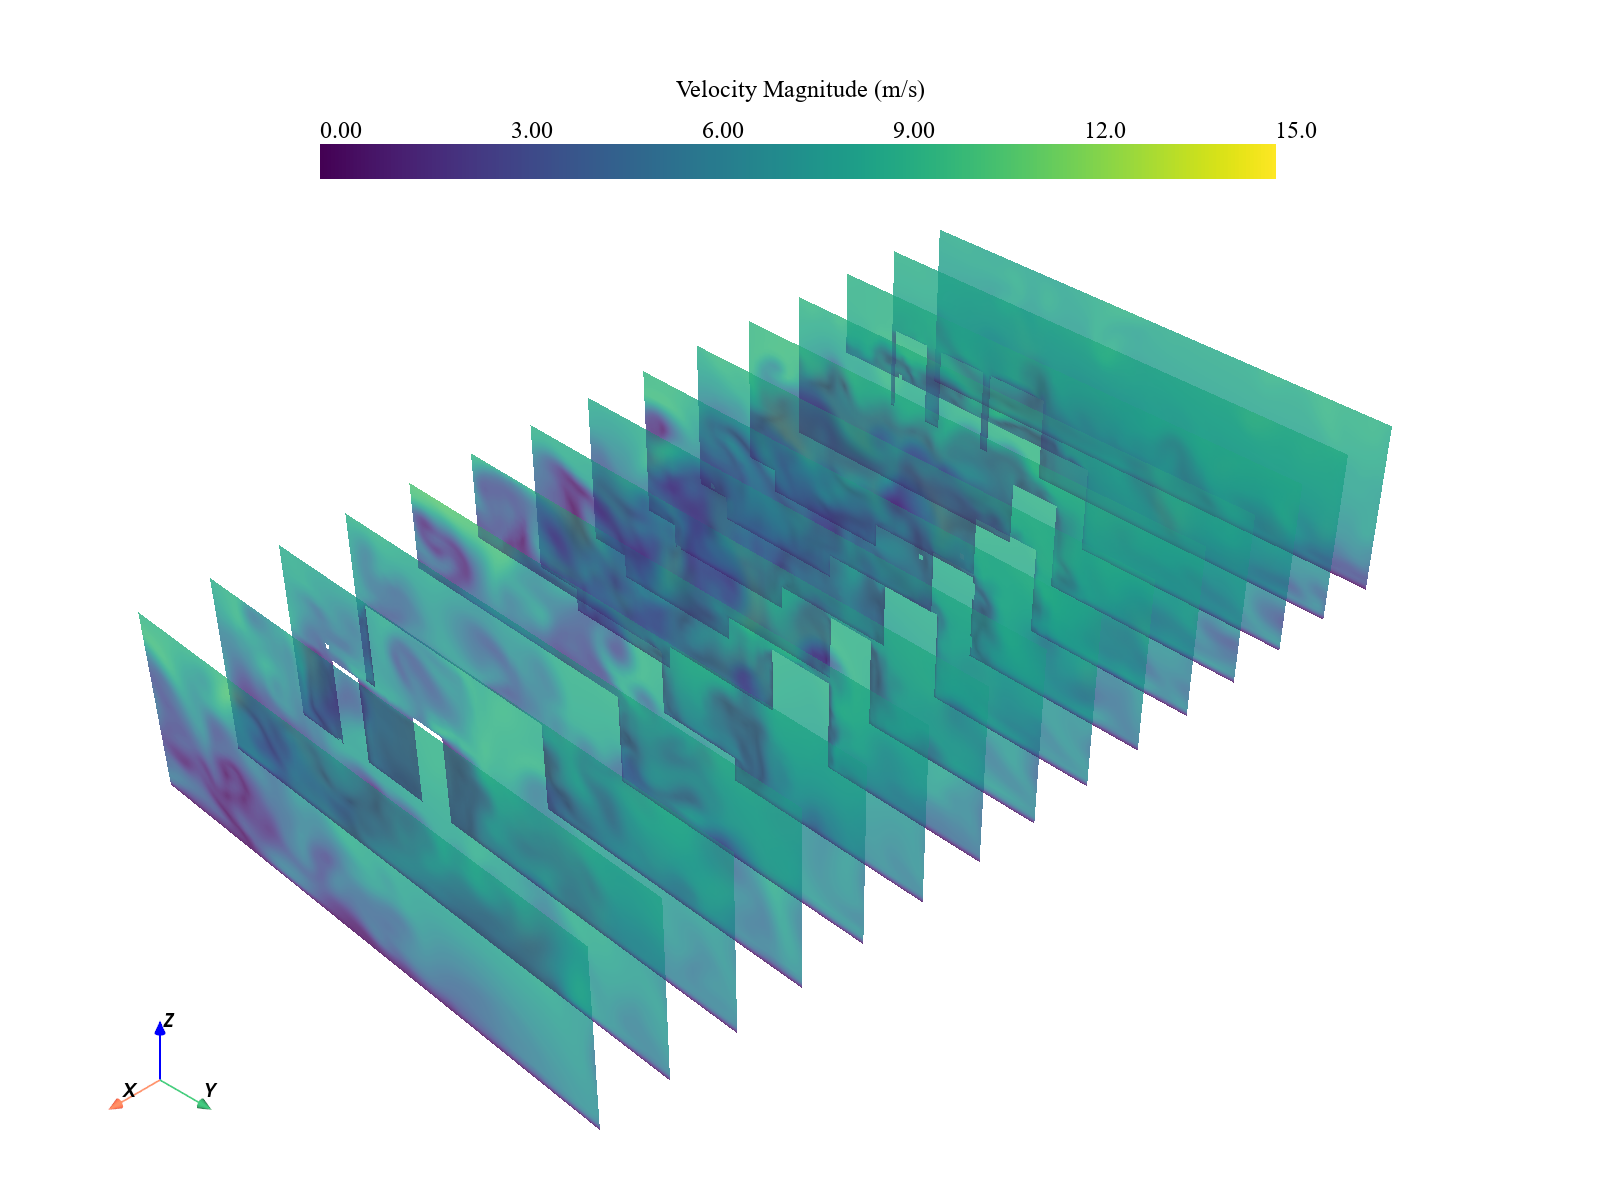

In [2]:
import pyvista as pv
import numpy as np

mesh = pv.read(r"../../wind/vtk_resampled/resampled_75.vtk")

x_positions = np.linspace(100, 500, 15)
plotter = pv.Plotter(lighting='none')

spacing = 20  # Space between slices
for i, x_pos in enumerate(x_positions):
    slice_x = mesh.slice(normal='x', origin=(x_pos, 0, 0))
    clipped_slice = slice_x.clip(normal=[-1, 0, 0], origin=[0, 0, 0])
    clipped_slice = clipped_slice.clip(normal=[0, 0, -1], origin=[0, 0, 0])
    clipped_slice = clipped_slice.clip(normal=[0, -1, 0], origin=[0, 70, 0])
    clipped_slice.translate((0, i*spacing, 0))
    u = clipped_slice.get_array('U')
    velocity_magnitude = np.linalg.norm(u, axis=1)
    clipped_slice['velocity_magnitude'] = velocity_magnitude
    plotter.add_mesh(clipped_slice, opacity=0.8, cmap='viridis', clim=[0, 15], show_scalar_bar=False)

bar = plotter.add_scalar_bar(
    title='Velocity Magnitude (m/s)\n',
    n_labels=6,
    title_font_size=24,
    label_font_size=24,
    position_x=0.2,
    position_y=0.85,
    font_family='times'
)

bar.GetTitleTextProperty().SetLineSpacing(1.01)

for _tp in (bar.GetTitleTextProperty(), bar.GetLabelTextProperty()):
    _tp.SetFontFamily(4)
    _tp.SetFontFile(r'C:\Windows\Fonts\times.ttf')
plotter.add_axes()
plotter.window_size = [1600, 1200]
plotter.camera.zoom(1.1)
plotter.show()